---

digital brain MEG pipeline

---

In [129]:
# autoload
%load_ext autoreload
%autoreload 2

# load pgl actions
from pgl import pglActions

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

load session

---

In [130]:

# Load the session
#loadSession = pglActions.loadSession()
#loadSession.configure()
#if loadSession: session = loadSession.run()

---

Load FieldLine data

---

In [131]:
# configure the load
loadFieldline = pglActions.loadFieldline()
loadFieldline.configure(dataPath='/Users/justin/Desktop/digitalbrain')


In [132]:
# and run it
newSession=loadFieldline.run()
if newSession: session = newSession

(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_105019_sub-S004_file-ThingsPilotRun07_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/sub-S004_file-ThingsPilotRun01_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_103412_sub-S004_file-ThingsPilotRun03_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_102956_sub-S004_file-ThingsPilotRun02_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_104244_sub-S004_file-ThingsPilotRun05_raw.fif
(loadFieldline:_run) Loading Fie

---

Concatenate raws

---

In [133]:
# configure the concatenation
mneConcatenate = pglActions.mneConcatenate()
mneConcatenate.configure(session, all=True)

In [134]:
# run the concatenation
newSession = mneConcatenate.run(session)
if newSession: session = newSession

(mneConcatenate:_run) 20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif has bads: ['L117_bz-s113', 'L203_bz-s67', 'L504_bz-s86',
'L605_bz-s90'], which do not match the most common set: ['L203_bz-s67', 'L504_bz-s86', 'L605_bz-s90']
(mneConcatenate:_run) 20260825_110653_sub-S004_file-ThingsPilotRun11_raw.fif has bads: ['L117_bz-s113', 'L203_bz-s67', 'L504_bz-s86',
'L605_bz-s90'], which do not match the most common set: ['L203_bz-s67', 'L504_bz-s86', 'L605_bz-s90']
(mneConcatenate:_run) 20260825_110245_sub-S004_file-ThingsPilotRun10_raw.fif has bads: ['L117_bz-s113', 'L203_bz-s67', 'L504_bz-s86',
'L605_bz-s90'], which do not match the most common set: ['L203_bz-s67', 'L504_bz-s86', 'L605_bz-s90']
(mneConcatenate:_run) Set bads for concatenation to: {'L504_bz-s86', 'L117_bz-s113', 'L605_bz-s90', 'L203_bz-s67'}


---

Set names of events

---

In [135]:
# configure the concatenation
mneConfigureEvents = pglActions.mneConfigureEvents()

# group all the things labels into one
grouped = {
    'things': range(2,201),
    'blank': 1022,
    'catch': 1023
}

# label each stimulus with its own name
each = {
    f"stimulus {code:03d}": code
    for code in range(2, 201)
}
each["blank"] = 1022
each["catch"] = 1023

triggerLabelSets = {
    "grouped": grouped,
    "each": each
}

# configure
mneConfigureEvents.configure(triggerChannel='di2', triggerShortestEvent=1, triggerLabelSets = triggerLabelSets)

Finding events on: di2
2290 events found on stim channel di2
Event IDs: [   2    3    4    5    6    7    8    9   10   11   12   13   14   15
   16   17   18   19   20   21   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   46   47   48   49   50   51   52   53   54   55   56   57
   58   59   60   61   62   63   64   65   66   67   68   69   70   71
   72   73   74   75   76   77   78   79   80   81   82   83   84   85
   86   87   88   89   90   91   92   93   94   95   96   97   98   99
  100  101  102  103  104  105  106  107  108  109  110  111  112  113
  114  115  116  117  118  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  143  144  145  146  147  148  149  150  151  152  153  154  155
  156  157  158  159  160  161  162  163  164  165  166  167  168  169
  170  171  172  173  174  175  176  177  178  179  180  181  182  183
  184

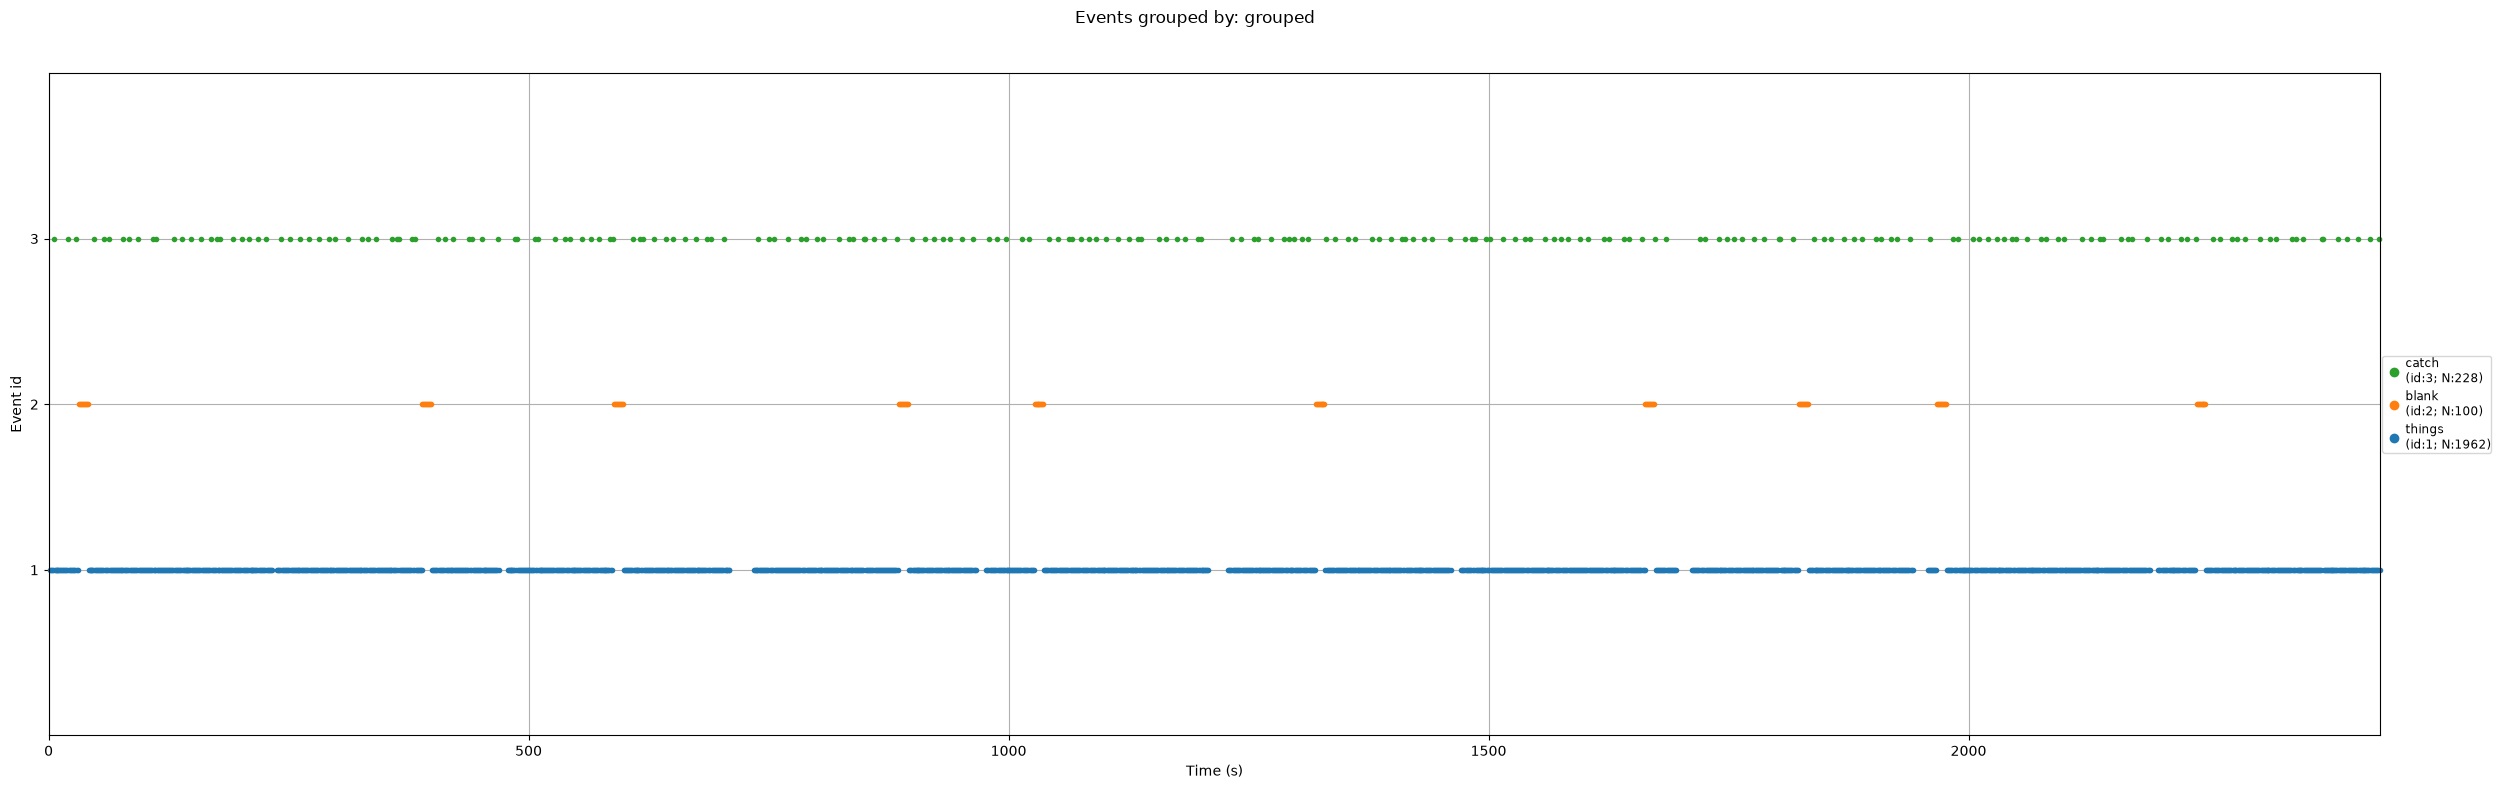

In [136]:
# configure the events
newSession = mneConfigureEvents.run(session)
if newSession: session = newSession

---

Filter data

---

In [137]:
mneFilter = pglActions.mneFilter()
mneFilter.configure(lowCutoff=0.5, highCutoff=40.0, notch=True, notchFrequency=60.0)

Filtering raw data in 10 contiguous segments
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Filter length: 6601 samples (6.601 s)

Filtering raw data in 10 contiguous segments
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 331 samples (0.331 s)

Filtering raw data in 10 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FI

/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


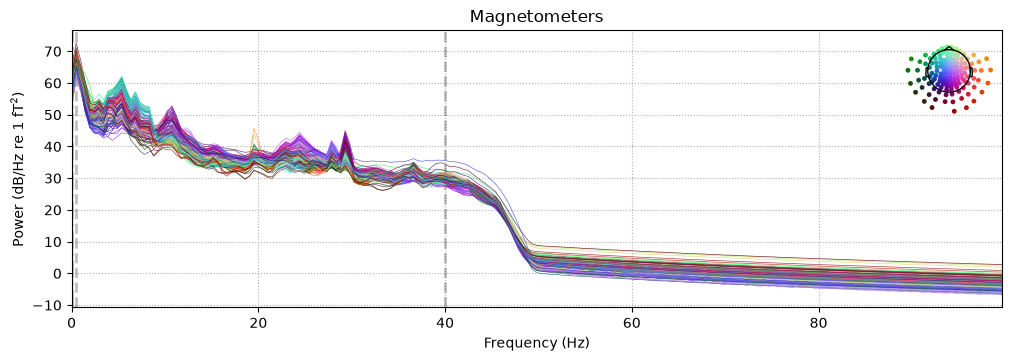

In [138]:
newSession = mneFilter.run(session)
if newSession: session = newSession

---

Bads handling

---

In [139]:
mneBads = pglActions.mneBads()
mneBads.configure(excludeWhenPositionIsNaN=True, extraBads=[], interpolationOrigin="zero", method="interpolate")

In [140]:
newSession = mneBads.run(session)
if newSession: session = newSession

+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
(mneBads:_run) Interpolating 4 bad sesnsors: ['L504_bz-s86', 'L117_bz-s113', 'L605_bz-s90', 'L203_bz-s67']
+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
Setting channel interpolation method to {'meg': 'MNE'}.
Interpolating bad channels.
    Computing dot products for 139 MEG channels...
    Computing cross products for 139 → 4 MEG channels...
    Preparing the mapping matrix...
    Truncating at 109/139 components to omit less than 0.0001 (9.8e-05)


---

create epochs

---

In [141]:
mneCreateEpochs = pglActions.mneCreateEpochs()
mneCreateEpochs.configure(tmin=0.0, tmax=1.0)

In [142]:
newSession = mneCreateEpochs.run(session)
if newSession: session = newSession

---

Plot evoked

---

In [143]:
mnePlotEvoked = pglActions.mnePlotEvoked()
mnePlotEvoked.configure(set="grouped",label="things")
#mnePlotEvoked.configure(set="each",label="stimulus 150")

No projector specified for this dataset. Please consider the method self.add_proj.


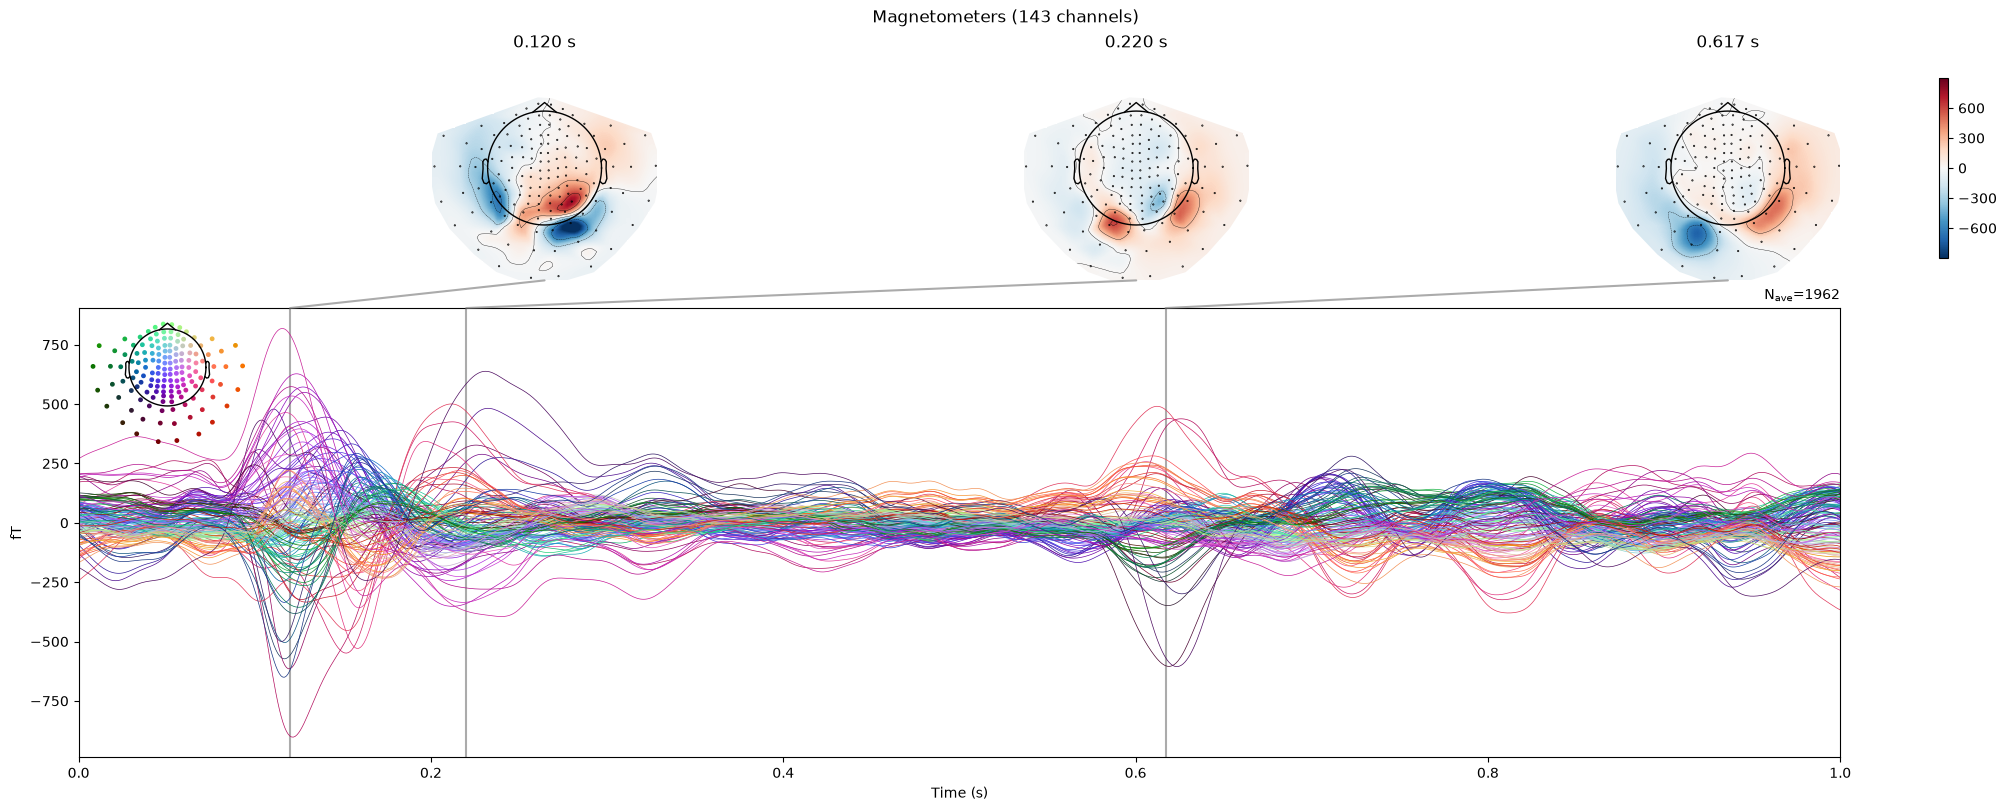

In [144]:
newSession = mnePlotEvoked.run(session)
if newSession: session = newSession

---

Downsample epochs

---

In [145]:
mneDownsampleEvoked = pglActions.mneDownsampleEvoked()
mneDownsampleEvoked.configure(downsampleFrequency=200)

In [146]:
newSession = mneDownsampleEvoked.run(session)
if newSession: session = newSession

---

Compute NCSNR

---

In [147]:
mneComputeNCSNR = pglActions.mneComputeNCSNR()
#mneComputeNCSNR.configure(set="grouped",label="things",conditionIDColumn="code",chType="mag",channelName="L213_bz-s115")
mneComputeNCSNR.configure(set="grouped",label="things",conditionIDColumn="code",chType="mag")
mneComputeNCSNR.configure(set="grouped",label="things",conditionIDColumn="code",chType="mag",channelName="L213_bz-s115")


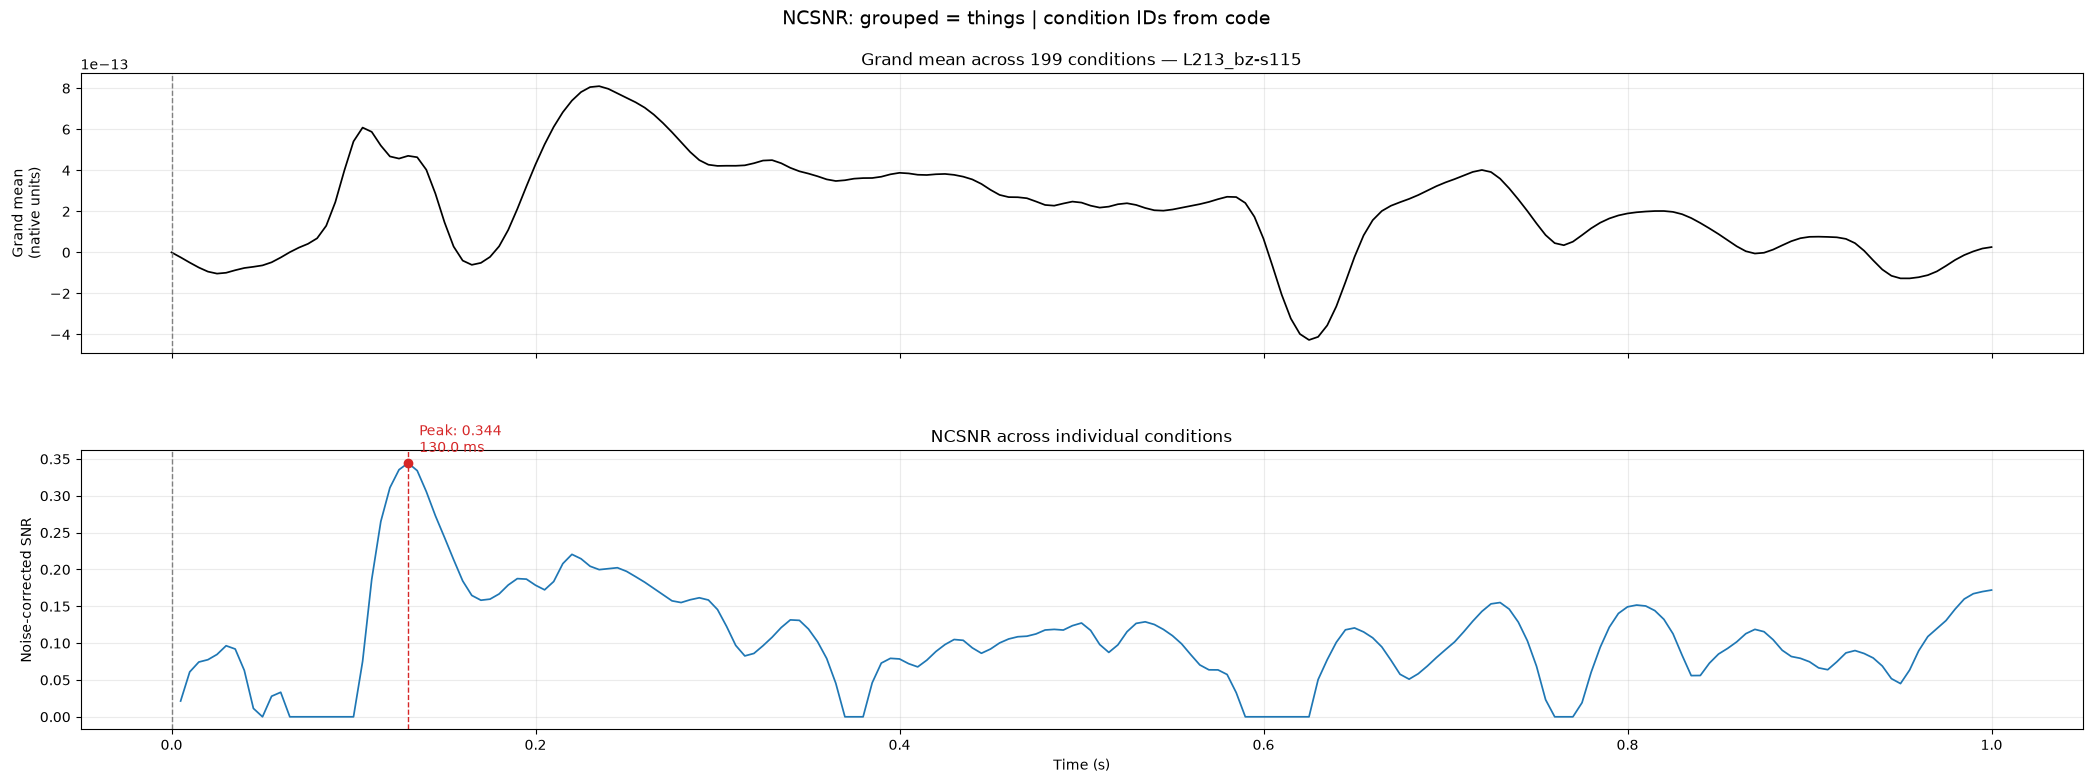

In [148]:
newSession = mneComputeNCSNR.run(session)
if newSession: session = newSession

---

History

---

In [149]:
session.history()

pglSession:
----------------------------------------
actionHistory                  [loadFieldline status: SUCCESS, mneConcatenate status: SUCCESS, mneConfigureEvents status: SUCCESS, mneFilter status: SUCCESS, mneBads status: SUCCESS, mneCreateEpochs status: SUCCESS, mnePlotEvoked status: SUCCESS, mneDownsampleEvoked status: SUCCESS, mneComputeNCSNR status: SUCCESS]
filesystem                     None
filesystemPrefix               
runs                           []
mne                            <pgl.pglSession.pglMNE object at 0x30767e930>
================================ action history ================================
0: loadFieldline ran at 14:10:54 16/09/2026 with status: SUCCESS duration: 1s 608ms
1: mneConcatenate ran at 14:10:56 16/09/2026 with status: SUCCESS duration: 353ms
2: mneConfigureEvents ran at 14:10:57 16/09/2026 with status: SUCCESS duration: 86ms
3: mneFilter ran at 14:10:57 16/09/2026 with status: SUCCESS duration: 21s 989ms
4: mneBads ran at 14:11:19 16/09/2026 

---

SCRATCH code

---

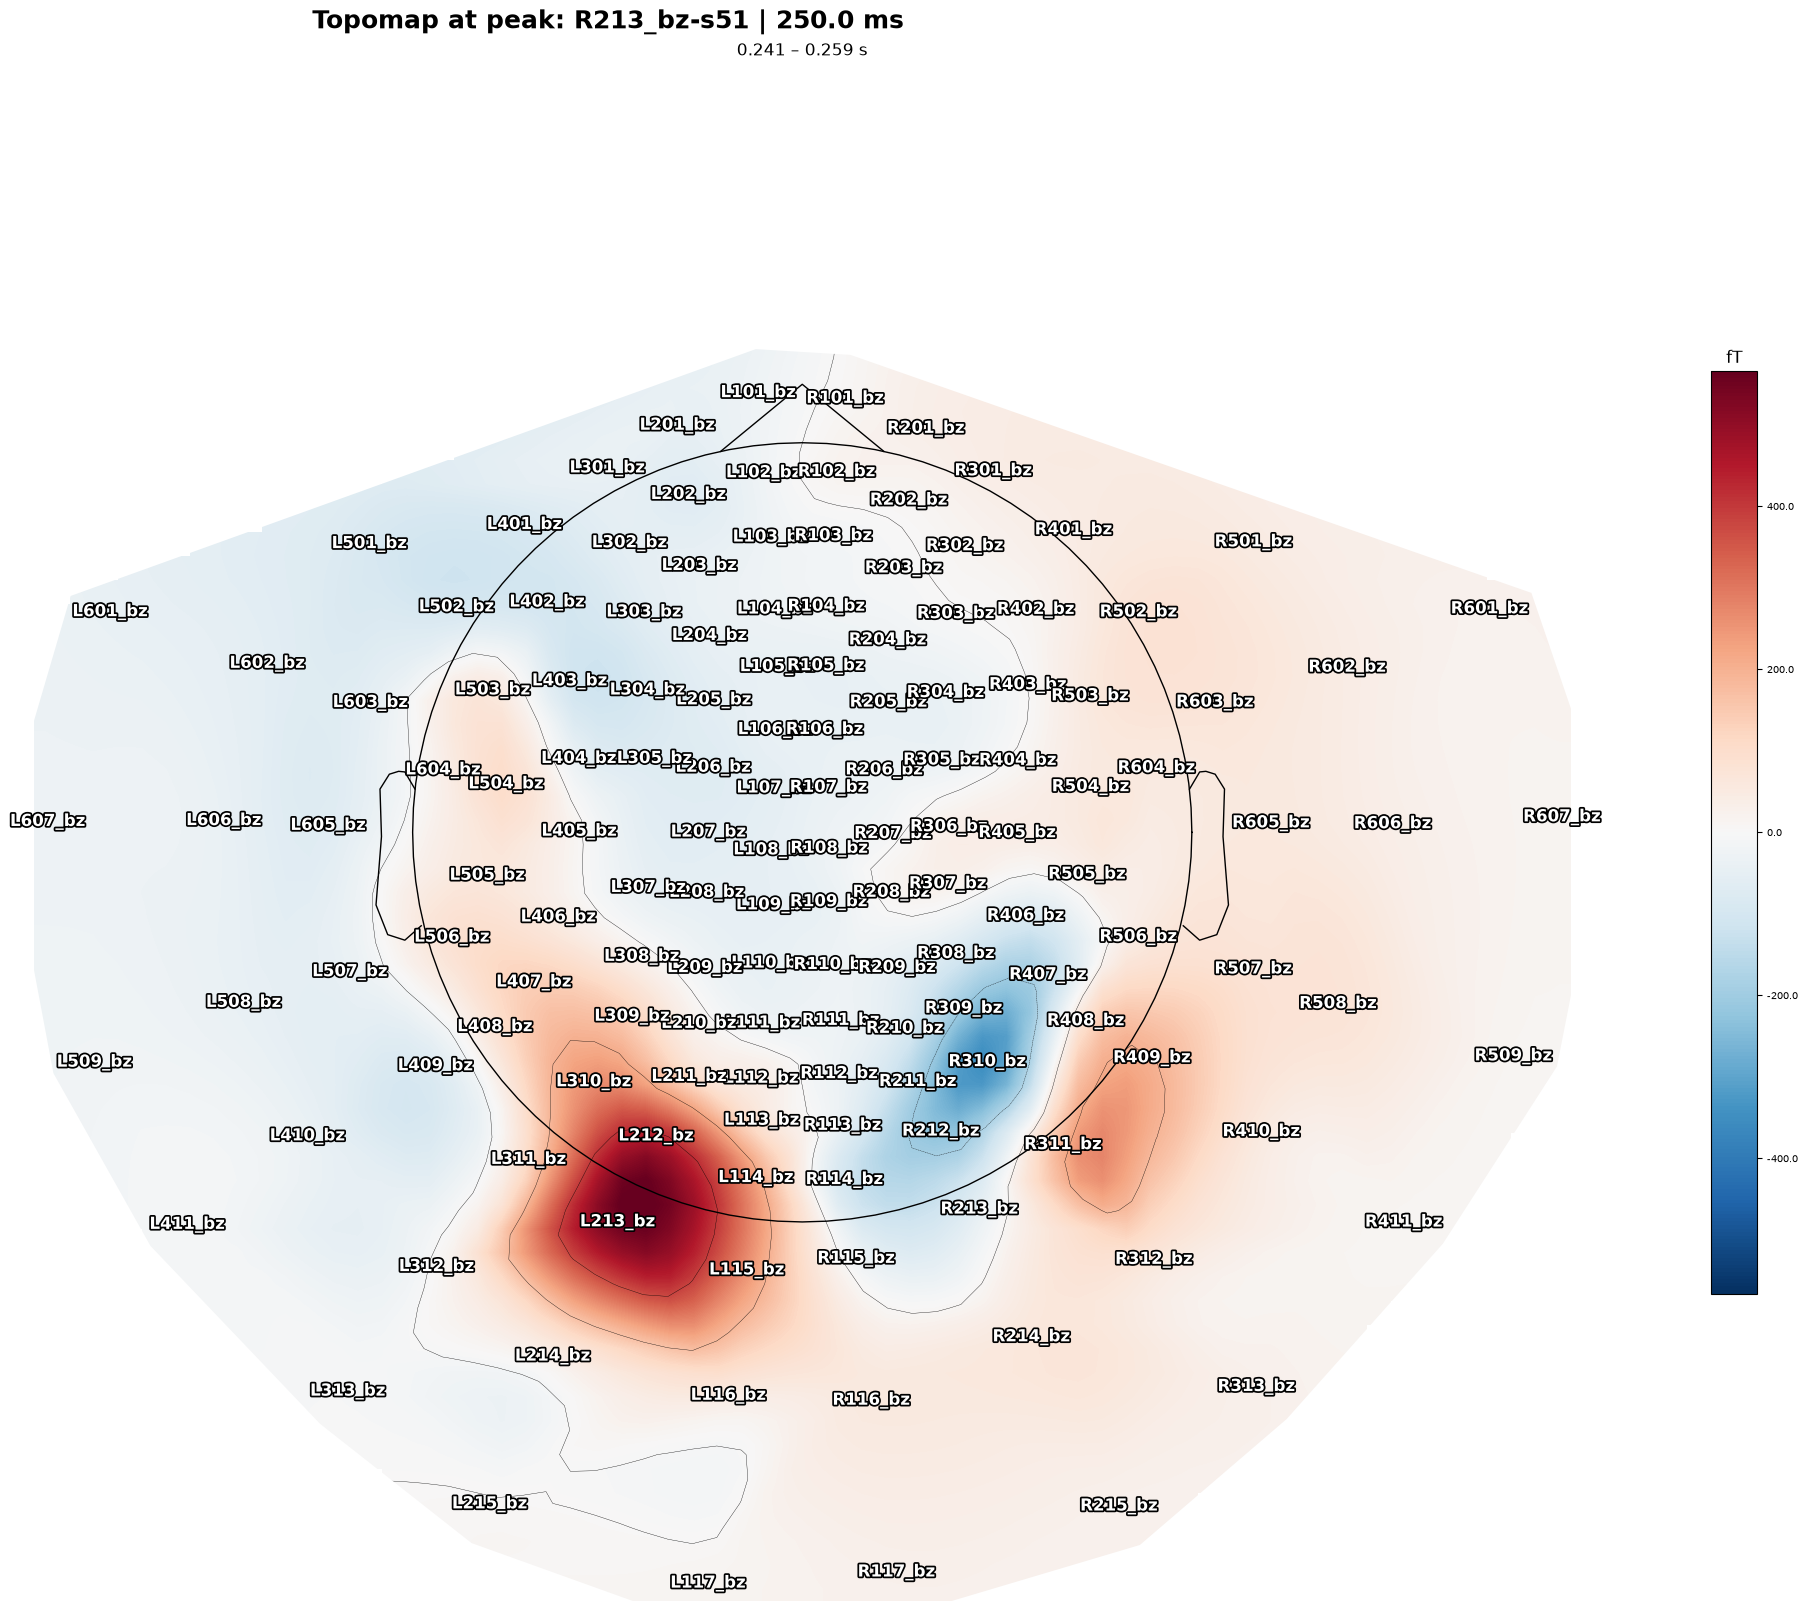

['L101_bz-s139', 'L102_bz-s129', 'L103_bz-s131', 'L104_bz-s137', 'L105_bz-s144', 'L106_bz-s140', 'L107_bz-s143', 'L108_bz-s133', 'L109_bz-s119', 'L110_bz-s114', 'L111_bz-s120', 'L112_bz-s127', 'L113_bz-s128', 'L114_bz-s122', 'L115_bz-s123', 'L116_bz-s117', 'L117_bz-s113', 'L201_bz-s76', 'L202_bz-s65', 'L203_bz-s67', 'L204_bz-s79', 'L205_bz-s66', 'L206_bz-s68', 'L207_bz-s73', 'L208_bz-s78', 'L209_bz-s126', 'L210_bz-s121', 'L211_bz-s125', 'L212_bz-s124', 'L213_bz-s115', 'L214_bz-s116', 'L215_bz-s118', 'L301_bz-s69', 'L302_bz-s75', 'L303_bz-s72', 'L304_bz-s70', 'L305_bz-s77', 'L307_bz-s71', 'L308_bz-s74', 'L309_bz-s107', 'L310_bz-s101', 'L311_bz-s105', 'L312_bz-s108', 'L313_bz-s99', 'L401_bz-s92', 'L402_bz-s89', 'L403_bz-s95', 'L404_bz-s82', 'L405_bz-s97', 'L406_bz-s104', 'L407_bz-s102', 'L408_bz-s103', 'L409_bz-s100', 'L410_bz-s112', 'L411_bz-s110', 'L501_bz-s94', 'L502_bz-s96', 'L503_bz-s87', 'L504_bz-s86', 'L505_bz-s85', 'L506_bz-s98', 'L507_bz-s106', 'L508_bz-s111', 'L509_bz-s109', 'L

In [150]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pathEffects

channelName, peakTime, peakAmplitude = session.mne.evoked.get_peak(ch_type="mag", mode="abs", return_amplitude=True)
peakTime=0.250
with plt.rc_context({"figure.constrained_layout.use": False, "figure.autolayout": False}):
    fig = session.mne.evoked.plot_topomap(
        times=peakTime,
        ch_type="mag",
        average=0.02,
        sensors=True,
        show_names=True,
        show=False,
    )

    fig.set_size_inches(24, 16, forward=True)

    # ax.texts contains the channel-name labels added to the topomap.
    for ax in fig.axes:
        for text in ax.texts:
            text.set_color("white")
            text.set_fontsize(12)
            text.set_fontweight("bold")
            text.set_path_effects([
                pathEffects.Stroke(linewidth=2.5, foreground="black"),
                pathEffects.Normal(),
            ])

    fig.suptitle(f"Topomap at peak: {channelName} | {peakTime * 1000:.1f} ms", fontsize=18, fontweight="bold")
    plt.show()
print(session.mne.evoked.ch_names)

In [151]:
session.mne.lookupSensor('L101')

'L101_bz-s139'

Do spectrum on the evoked averages - take the mean of the 3000 trials in time domain and transform last
do it over 2 seconds - you should see nothing at 0.5Hz 



In [152]:
loadFieldline